In [1]:
import pickle
with open('hp_eval.pkl', 'rb') as f:
    pid_eval_dict = pickle.load(f)

In [2]:
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
with open('handpicked_dataset.pkl', 'rb') as f:
    (go_domain_df, prot_dict) = pickle.load(f)
import matplotlib.pyplot as plt
import numpy as np

In [3]:
with open('hp_logits.pkl', 'rb') as f:
   logit_eval_dict = pickle.load(f)

import torch
def logit_entropy(logit_l, base_ind, max_len=800):
    max_entr = np.log(len(base_ind))
    entropy_val = np.zeros((len(logit_l), max_len+1)) + max_entr
    for i, bert_logit in enumerate(logit_l):
        sl = bert_logit.shape[0]-2
        p = torch.softmax(bert_logit.cpu()[:, base_ind], dim=-1)
        res_entropy_imp = -(torch.log(p)*p).sum(dim=-1)
        entropy_val[i, 1:sl+1] = res_entropy_imp[1:-1].numpy()
    return entropy_val

base_ind = list(range(4, 24))
entropy_eval_dict = {k:logit_entropy(ll, base_ind, max_len=800) for k, ll in logit_eval_dict.items()}

pid_entropy_dict = {}
for i, (pid, seq) in enumerate(prot_dict.items()):
    pid_entropy_dict[pid] = entropy_eval_dict['perc'][i]

In [4]:
score_l = []
for i in range(len(go_domain_df)):
    pid, go_ind, domain_mask = tuple(go_domain_df.iloc[i])
    # print(pid, go_ind)
    eval_mat = pid_eval_dict[pid]
    scores = -eval_mat[:, :, go_ind].var(axis=1)
    score_l.append(scores)

hscore_l = []
for i in range(len(go_domain_df)):
    pid, go_ind, domain_mask = tuple(go_domain_df.iloc[i])
    # print(pid, go_ind)
    scores = -pid_entropy_dict[pid][:domain_mask.shape[0]]
    hscore_l.append(scores)

In [5]:
def precision_top_k(domain_mask, scores, k):
    top_k_predicted_indices = np.argsort(scores)[-k:]
    true_positives = domain_mask[top_k_predicted_indices].sum()
    precision = true_positives / k
    return precision

def get_avg_precision(domain_mask_l, scores, k):
    precisions = np.zeros(len(scores))
    for i, domain_mask in enumerate(domain_mask_l):
        # print(scores[i].mean())
        precisions[i] = precision_top_k(domain_mask, scores[i], k)
    return np.mean(precisions)

def rand_precision(iterator, scores):
    precisions = np.zeros(len(scores))
    for i, domain_mask in enumerate(iterator):
        precisions[i] = np.mean(domain_mask)
    return np.mean(precisions)

print(get_avg_precision(go_domain_df['Domain Mask'], score_l, 1))
print(rand_precision(go_domain_df['Domain Mask'], score_l))
print(get_avg_precision(go_domain_df['Domain Mask'], hscore_l, 1))

0.3157894736842105
0.3830829144047588
0.5263157894736842


In [6]:
from go_ml.go_utils import godag, go2parents_isa, get_ancestors
train_path="/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)

../go-basic.obo: fmt(1.2) rel(2024-04-24) 45,667 Terms


In [7]:
ancestors = get_ancestors(go_terms[go_ind], go2parents_isa)
ancestor_ind = [go_terms.index(a) for a in ancestors]
ancestor_ind

ValueError: 'GO:0005488' is not in list

In [8]:
var_mat = eval_mat.var(axis=1)

Q02226 17


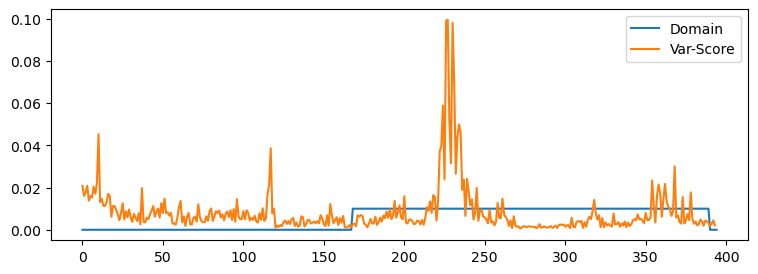

In [14]:
ind = 4
pid, go_ind, domain_mask = tuple(go_domain_df.iloc[ind])
print(pid, go_ind)
eval_mat = pid_eval_dict[pid]
# plt.plot((-pid_entropy_dict[pid][:domain_mask.shape[0]] + 3)*1e-2, label='H-Score')
fig, ax = plt.subplots(1,1, figsize=(9,3))
ax.plot(domain_mask*1e-2, label='Domain')
ax.plot(eval_mat[:, :, go_ind].var(axis=1), label='Var-Score')
# ax.plot(eval_mat[:, :, 17].var(axis=1), label=f'Var-Score {17}')
# ax.plot(eval_mat[:, :, 21].var(axis=1), label=f'Var-Score {21}')
# ax.plot(eval_mat[:, :, go_ind].var(axis=1) - var_mat.mean(axis=1), label=f'Var-Score Mean')

ax.legend()
fig.show()
# plt.show()
# plt.imshow(eval_mat[:, :, go_ind].T)


In [52]:
import pickle
with open('handpicked_dataset.pkl', 'rb') as f:
    go_domain_df, prot_dict = pickle.load(f)

import numpy as np
import pandas as pd
from go_ml.train_utils import get_enzyme_df, enzyme_iterator, cls_seq_encode
import transformers
import matplotlib.pyplot as plt
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
from go_ml.go_utils import godag, go2parents_isa, get_ancestors

aa_str = 'LAGVSERTIDPKQNFYMHWC'
aa_ind = [tokenizer.get_vocab()[c] for c in aa_str]

import torch
device = torch.device('cuda:0')
from go_ml.models.bert_finetune import BERTFinetune
checkpoint_dir = "/home/andrew/GO_interp/checkpoints"
model = BERTFinetune.load_from_checkpoint(f"{checkpoint_dir}/esm_finetune-v1.ckpt", map_location=device)
model.eval()
print("Model loaded")

pid_eval_dict = {}
from tqdm import tqdm
for prot_id, prot_seq in prot_dict.items():
    eval_ind = list(range(1, 1+len(prot_seq)))
    aa_str = 'LAGVSERTIDPKQNFYMHWC'
    aa_ind = [tokenizer.get_vocab()[c] for c in aa_str]
    eval_dict = {}
    seq_data = cls_seq_encode(prot_seq.upper(), tokenizer)
    with torch.no_grad():
        aa_ind = torch.tensor(aa_ind, device=device)
        seq_ind, mask =  torch.tensor(seq_data['seq_ind']).to(device), torch.BoolTensor(seq_data['mask']).to(device)
        seq_ind = seq_ind[:, :len(prot_seq) + 2]
        mask = mask[:, :len(prot_seq) + 2]
        base_batch_seq = torch.tile(seq_ind, (aa_ind.shape[0], 1))
        batch_mask = torch.tile(mask, (aa_ind.shape[0], 1))
        for res_ind in tqdm(eval_ind):
            batch_seq = base_batch_seq.clone()
            batch_seq[:, res_ind] = aa_ind
            print(res_ind, batch_seq.shape)
            logits = model.forward(batch_seq, mask)
            eval_dict[res_ind] = logits.cpu().numpy()
    eval_mat = np.stack([eval_dict[i] for i in range(1, len(eval_dict)+1)])
    pid_eval_dict[prot_id] = eval_mat

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded


  0%|          | 0/488 [00:00<?, ?it/s]

1 torch.Size([20, 490])


  0%|          | 1/488 [00:01<08:21,  1.03s/it]

...

5 torch.Size([20, 490])


  1%|          | 5/488 [00:05<08:18,  1.03s/it]

6 torch.Size([20, 490])


  1%|          | 5/488 [00:06<09:58,  1.24s/it]


KeyboardInterrupt: 

In [49]:
eval_mat = np.stack([eval_dict[i] for i in range(1, len(eval_dict)+1)])

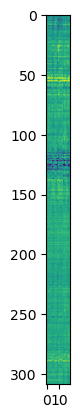

In [93]:
plt.imshow(eval_mat[:, :, 10])

[[ 1.0517317  -0.18057248  1.2613817  ...  1.2613817   1.2613817
   1.2613817 ]
 [ 0.2020972   1.0183027   1.2613817  ...  1.2613817   1.2613817
   1.2613817 ]
 [-0.46666208  0.8038044   1.2613817  ...  1.2613817   1.2613817
   1.2613817 ]
 ...
 [-0.37702224  0.51584506  1.2613817  ...  1.2613817   1.2613817
   1.2613817 ]
 [-0.19669473  0.35303918  1.2613817  ...  1.2613817   1.2613817
   1.2613817 ]
 [ 0.7237859   0.02647574  1.2613817  ...  1.2613817   1.2613817
   1.2613817 ]]


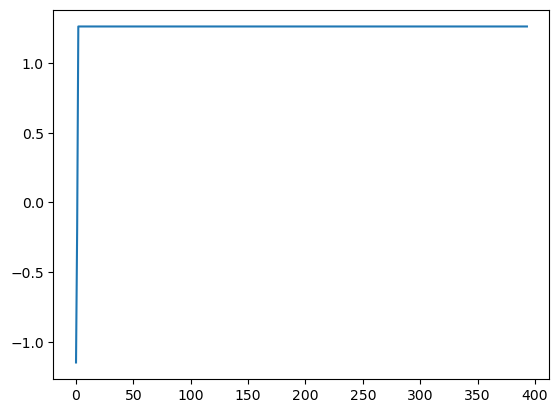

In [14]:
print(eval_mat[:, :, 1].T)
plt.plot(np.min(eval_mat[:, :, 1] , axis=1))